# DATASET DOWNLOAD

In [1]:
import zipfile, os

with zipfile.ZipFile("/kaggle/input/notebooks/digvijaysinhpawar/notebookccff0afafb/_output_.zip", "r") as z:
    z.extractall("/kaggle/working/")

# Verify files are there
os.listdir("/kaggle/working/")

['mask_rcnn_finetune_best.pth',
 '.cache',
 'training_histories.pkl',
 'mask_rcnn_finetune_bare.pth',
 '__pycache__',
 'training_results_task3_2.txt',
 'dataset_splits.json',
 'val',
 'train',
 'label_map.json',
 '__notebook__.ipynb']

# TASK 3.2 : Mask R-CNN — Detection & Segmentation

"""
MASK R-CNN TRAINING SCRIPT FOR TASK 3.2
Strategy  : finetune (pretrained COCO weights, differential LR)
Data split:
  train_paths — from train_clean, stems in dataset_splits.json ["train"]
  val_paths   — from validation_clean (val_clean), used for live validation & checkpointing
  test_paths  — from train_clean, stems in dataset_splits.json ["val"]  (held-out test)
"""

## Imports

In [2]:
import torch
import torchvision
import json
import os
import cv2
import numpy as np
import logging
from tqdm import tqdm
from glob import glob
from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import random
import gc
from collections import defaultdict
from torchvision import transforms as T


### Logging Setup

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler("training_results_task3_2.txt"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()
logger.info("=" * 60)
logger.info("MASK R-CNN PIPELINE - TASK 3.2")
logger.info("=" * 60)


2026-03-20 06:01:19,807 [INFO] ============================================================
2026-03-20 06:01:19,808 [INFO] MASK R-CNN PIPELINE - TASK 3.2
2026-03-20 06:01:19,809 [INFO] ============================================================


## Configuration & Data Splits

In [4]:
CATEGORIES = ["short sleeve top", "trousers", "shorts", "long sleeve top", "skirt"]
CAT_TO_IDX = {cat: i + 1 for i, cat in enumerate(CATEGORIES)}
IDX_TO_CAT = {v: k for k, v in CAT_TO_IDX.items()}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


2026-03-20 06:01:19,888 [INFO] Using device: cuda


### Train / Test Splits (from dataset_splits.json)

In [5]:
import json, os, glob as glob_module

with open("/kaggle/working/dataset_splits.json", "r") as f:
    splits = json.load(f)

train_stems = splits["train"]
val_stems   = splits["val"]

logger.info(f"  Train stems : {len(train_stems)}")
logger.info(f"  Val   stems : {len(val_stems)}")

def stems_to_paths(stems):
    paths = []
    for stem in stems:
        p = f"/kaggle/working/train/train/annos/{stem}.json"
        if os.path.exists(p):
            paths.append(p)
    return paths

train_paths = stems_to_paths(train_stems)
val_paths   = stems_to_paths(val_stems)
logger.info(f"Resolved train JSONs : {len(train_paths)}")
logger.info(f"Resolved val   JSONs : {len(val_paths)}")

2026-03-20 06:01:19,931 [INFO]   Train stems : 20231
2026-03-20 06:01:19,932 [INFO]   Val   stems : 3571
2026-03-20 06:01:20,030 [INFO] Resolved train JSONs : 20231
2026-03-20 06:01:20,031 [INFO] Resolved val   JSONs : 3571


### Val Split (from validation_clean — live val during training)

In [6]:
test_paths = sorted(glob_module.glob("/kaggle/working/val/validation/annos/*.json"))
logger.info(f"Test (val_clean) JSONs : {len(test_paths)}")

2026-03-20 06:01:20,106 [INFO] Test (val_clean) JSONs : 23741


## Dataset Class

In [7]:
class DeepFashionMaskRCNNDataset(Dataset):
    def __init__(self, json_paths, augment=False, img_size=640):
        self.json_paths = json_paths
        self.augment    = augment
        self.img_size   = img_size

    def __len__(self):
        return len(self.json_paths)

    def __getitem__(self, idx):
        json_path = self.json_paths[idx]
        img_path  = json_path.replace(".json", ".jpg").replace("annos", "image")
        if not os.path.exists(img_path):
            img_path = json_path.replace(".json", ".jpg")

        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size   # captured BEFORE augmentation (flip keeps size)

        with open(json_path, "r") as f:
            data = json.load(f)

        boxes, labels, polygons = [], [], []
        for key, value in data.items():
            if key.startswith("item") and isinstance(value, dict):
                cat_name = value.get("category_name")
                if cat_name in CAT_TO_IDX:
                    boxes.append(value.get("bounding_box"))
                    labels.append(CAT_TO_IDX[cat_name])
                    polygons.append(value.get("segmentation", []))

        if self.augment:
            image, boxes, polygons = self._augment(image, boxes, polygons, orig_w, orig_h)

        # Resize to model input size
        image = image.resize((self.img_size, self.img_size))
        w = h = self.img_size
        scale_x = w / orig_w
        scale_y = h / orig_h

        scaled_boxes, final_labels, masks = [], [], []
        for bbox, label, poly_list in zip(boxes, labels, polygons):
            sb = [bbox[0]*scale_x, bbox[1]*scale_y, bbox[2]*scale_x, bbox[3]*scale_y]
            if sb[2] > sb[0] and sb[3] > sb[1]:    # skip degenerate boxes
                scaled_boxes.append(sb)
                final_labels.append(label)
                mask = np.zeros((h, w), dtype=np.uint8)
                for poly in poly_list:
                    poly_np = np.array(poly, dtype=np.float32).reshape((-1, 2))
                    poly_np[:, 0] *= scale_x
                    poly_np[:, 1] *= scale_y
                    cv2.fillPoly(mask, [poly_np.astype(np.int32)], 1)
                masks.append(mask)

        if len(scaled_boxes) == 0:
            boxes_t  = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,),   dtype=torch.int64)
            masks_t  = torch.zeros((0, h, w), dtype=torch.uint8)
        else:
            boxes_t  = torch.as_tensor(scaled_boxes,    dtype=torch.float32)
            labels_t = torch.as_tensor(final_labels,    dtype=torch.int64)
            masks_t  = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes":    boxes_t,
            "labels":   labels_t,
            "masks":    masks_t,
            "image_id": torch.tensor([idx])
        }
        return transforms.ToTensor()(image), target

    def _augment(self, image, boxes, polygons, width, height):
        # Horizontal flip (50%)
        if random.random() < 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            boxes = [[width - b[2], b[1], width - b[0], b[3]] for b in boxes]
            polygons = [
                [[width - pt if i % 2 == 0 else pt for i, pt in enumerate(poly)]
                 for poly in pl]
                for pl in polygons
            ]
        # Colour jitter (70%) — does not affect geometry
        if random.random() < 0.7:
            for Cls, lo, hi in [
                (ImageEnhance.Brightness, 0.8, 1.2),
                (ImageEnhance.Contrast,   0.8, 1.2),
                (ImageEnhance.Color,      0.8, 1.2),
            ]:
                image = Cls(image).enhance(random.uniform(lo, hi))
        return image, boxes, polygons


def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    DeepFashionMaskRCNNDataset(train_paths, augment=True,  img_size=640),
    batch_size=2, shuffle=True,  num_workers=2, collate_fn=collate_fn, pin_memory=True
)
val_loader = DataLoader(
    DeepFashionMaskRCNNDataset(val_paths,   augment=False, img_size=640),
    batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=True
)
test_loader = DataLoader(
    DeepFashionMaskRCNNDataset(test_paths,  augment=False, img_size=640),
    batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=True
)
logger.info(f"Loaders — train:{len(train_loader)} | val:{len(val_loader)} | test:{len(test_loader)} batches")


2026-03-20 06:01:20,497 [INFO] Loaders — train:10116 | val:1786 | test:11871 batches


## Model Initialisation

In [8]:
def get_mask_rcnn(num_classes, strategy="finetune"):
    """
    strategy = 'finetune' : pretrained COCO weights, differential LR
    strategy = 'scratch'  : random weights, no pretrained backbone
    num_classes includes background (len(CATEGORIES) + 1)
    """
    if strategy == "scratch":
        logger.info("Initialising from SCRATCH (random weights)")
        model = torchvision.models.detection.maskrcnn_resnet50_fpn(
            weights=None, weights_backbone=None, min_size=640, max_size=640
        )
    elif strategy in {"finetune", "transfer"}:
        logger.info("Fine-tuning with pretrained COCO weights")
        model = torchvision.models.detection.maskrcnn_resnet50_fpn(
            weights="DEFAULT", min_size=640, max_size=640
        )
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Replace box classification head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Replace mask head
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    return model


## Metrics: mAP, mIoU, Dice, Precision/Recall/F1, AUC

In [9]:
# ═══════════════════════════════════════════════════════════════════
# SEGMENTATION METRICS — instance-level greedy IoU matching
#
#   For each matched (TP) pair:
#       IoU  = |pred ∩ gt| / |pred ∪ gt|
#       Dice = 2|pred ∩ gt| / (|pred| + |gt|)
#   Unmatched predictions (FP) and unmatched GTs (FN) → score = 0
#   Denominator = TP + FP + FN  =  P + G − TP
#   avg_metric  = Σ(metric for matched TPs) / (P + G − TP)
# ═══════════════════════════════════════════════════════════════════
def calculate_segmentation_metrics_matched(pred_masks_list, gt_masks_list):
    """
    Returns (sum_iou, sum_dice, total_instances)
    where total_instances = TP + FP + FN
    """
    G = len(gt_masks_list)
    P = len(pred_masks_list)

    if G == 0 and P == 0:
        return 0.0, 0.0, 0
    if G == 0:
        return 0.0, 0.0, P    # all P predictions are FP
    if P == 0:
        return 0.0, 0.0, G    # all G GTs are FN

    iou_mat  = np.zeros((G, P), dtype=np.float64)
    dice_mat = np.zeros((G, P), dtype=np.float64)

    for i, gm in enumerate(gt_masks_list):
        ag = float(gm.sum())
        for j, pm in enumerate(pred_masks_list):
            inter = float((gm & pm).sum())
            union = float((gm | pm).sum())
            iou_mat[i, j]  = inter / union if union > 0 else 0.0
            denom = ag + float(pm.sum())
            dice_mat[i, j] = (2.0 * inter) / denom if denom > 0 else 0.0

    best_iou  = np.zeros(G, dtype=np.float64)
    best_dice = np.zeros(G, dtype=np.float64)
    work     = iou_mat.copy()
    tp_count = 0

    while True:
        g_idx, p_idx = np.unravel_index(np.argmax(work), work.shape)
        if work[g_idx, p_idx] < 0.5:
            break
        best_iou[g_idx]  = work[g_idx, p_idx]
        best_dice[g_idx] = dice_mat[g_idx, p_idx]
        tp_count += 1
        work[g_idx, :] = -1.0
        work[:, p_idx] = -1.0

    total_instances = P + G - tp_count    # TP + FP + FN
    return float(best_iou.sum()), float(best_dice.sum()), total_instances


# ═══════════════════════════════════════════════════════════════════
# DETECTION METRICS — greedy one-to-one matching at IoU threshold
#
#   Sort predictions by descending confidence score.
#   For each prediction, match to the highest-IoU unmatched GT.
#   If IoU >= threshold → TP, else → FP. Unmatched GTs → FN.
#
#   Precision = TP / (TP + FP)
#   Recall    = TP / (TP + FN)
#   F1        = 2 × Precision × Recall / (Precision + Recall)
# ═══════════════════════════════════════════════════════════════════
def box_iou_matrix(boxes1, boxes2):
    """Compute IoU matrix for two sets of xyxy boxes (numpy arrays)."""
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float64)
    b1  = boxes1.astype(np.float64)
    b2  = boxes2.astype(np.float64)
    iou = np.zeros((len(b1), len(b2)), dtype=np.float64)
    for i, (x1, y1, x2, y2) in enumerate(b1):
        a1 = max(0.0, x2 - x1) * max(0.0, y2 - y1)
        for j, (xx1, yy1, xx2, yy2) in enumerate(b2):
            a2    = max(0.0, xx2 - xx1) * max(0.0, yy2 - yy1)
            iw    = max(0.0, min(x2, xx2) - max(x1, xx1))
            ih    = max(0.0, min(y2, yy2) - max(y1, yy1))
            inter = iw * ih
            union = a1 + a2 - inter
            iou[i, j] = inter / union if union > 0 else 0.0
    return iou


def greedy_match_detection(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    """
    Greedy matching sorted by descending score.
    Returns tp_flags, fp_flags (score-sorted order) and fn_count.
    """
    n_pred = len(pred_boxes)
    n_gt   = len(gt_boxes)

    if n_pred == 0:
        return np.zeros(0, np.int64), np.zeros(0, np.int64), n_gt

    order       = np.argsort(-pred_scores)
    pred_boxes  = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou        = box_iou_matrix(pred_boxes, gt_boxes)
    matched_gt = np.zeros(n_gt, dtype=bool)
    tp = np.zeros(n_pred, dtype=np.int64)
    fp = np.zeros(n_pred, dtype=np.int64)

    for i in range(n_pred):
        if n_gt == 0:
            fp[i] = 1
            continue
        best_gt  = int(np.argmax(iou[i]))
        best_iou = iou[i, best_gt]
        if best_iou >= iou_thr and not matched_gt[best_gt]:
            tp[i] = 1
            matched_gt[best_gt] = True
        else:
            fp[i] = 1

    fn = int((~matched_gt).sum())
    return tp, fp, fn

_trapz = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
# ═══════════════════════════════════════════════════════════════════
# ROC-AUC (scalar, no sklearn dependency)
# ═══════════════════════════════════════════════════════════════════
def binary_roc_auc(y_true, y_score):
    """Trapezoid-rule ROC-AUC. Returns NaN if only one class present."""
    y_true  = np.asarray(y_true,  dtype=np.int64)
    y_score = np.asarray(y_score, dtype=np.float64)
    if len(y_true) == 0:
        return float("nan")
    pos = int((y_true == 1).sum())
    neg = int((y_true == 0).sum())
    if pos == 0 or neg == 0:
        return float("nan")
    thresholds = np.concatenate(([np.inf], np.unique(y_score)[::-1]))
    tpr_list, fpr_list = [], []
    for thr in thresholds:
        y_pred = (y_score >= thr).astype(np.int64)
        tp_ = int(((y_pred == 1) & (y_true == 1)).sum())
        fp_ = int(((y_pred == 1) & (y_true == 0)).sum())
        tpr_list.append(tp_ / pos)
        fpr_list.append(fp_ / neg)
    return float(_trapz(np.array(tpr_list), x=np.array(fpr_list)))


# ═══════════════════════════════════════════════════════════════════
# MAIN EVALUATION FUNCTION
# ═══════════════════════════════════════════════════════════════════
@torch.no_grad()
def evaluate_model(model, loader, device, epoch=None, det_iou_thr=0.5):
    """
    Computes:
      - COCO detection mAP@[0.5:0.95] and mAP@0.5  (via torchmetrics)
      - Instance-level global mIoU and Dice          (denominator = TP+FP+FN)
      - Per-class mIoU and Dice + macro averages
      - Per-class Precision, Recall, F1              (@IoU=0.5 match, score>=0.5)
      - Per-class ROC-AUC                            (ALL predictions, no score threshold)

    NOTE on ROC vs P/R/F1 thresholding:
      P/R/F1 use predictions filtered at score>=0.5 (standard operating point).
      ROC-AUC accumulates ALL predictions (unfiltered) so sklearn/our roc_curve
      can sweep the full [0, 1] confidence range to trace the complete curve.
    """
    model.eval()
    map_metric = MeanAveragePrecision(iou_type="bbox")

    total_iou       = 0.0
    total_dice      = 0.0
    total_instances = 0

    class_ids = list(CAT_TO_IDX.values())

    per_class_seg = {idx: {"sum_iou": 0.0, "sum_dice": 0.0, "total_instances": 0}
                     for idx in class_ids}

    # For P/R/F1 — uses score >= 0.5 filtered predictions
    per_class_det = {idx: {"tp": 0, "fp": 0, "fn": 0} for idx in class_ids}

    # For ROC curves — accumulates ALL predictions, no score threshold
    # tp_label=1 if prediction is a TP at iou_thr, 0 if FP
    per_class_roc = {idx: {"scores": [], "tp_labels": []} for idx in class_ids}

    tag = f"Epoch {epoch}" if epoch is not None else "Eval"
    logger.info(f"{tag} — evaluation starting...")

    for imgs, targets in tqdm(loader, desc="Evaluating", leave=False):
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        preds   = model(imgs)

        # COCO-style detection mAP (no score threshold — torchmetrics handles it)
        map_metric.update(
            [{"boxes": p["boxes"].cpu(), "scores": p["scores"].cpu(),
              "labels": p["labels"].cpu()} for p in preds],
            [{"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()} for t in targets]
        )

        for p, t in zip(preds, targets):
            # ── Build mask lists (filtered at 0.5 for segmentation) ──
            pred_masks_l, pred_labels_l = [], []
            if len(p.get("masks", [])) > 0:
                for m, lbl, sc in zip(p["masks"], p["labels"], p["scores"]):
                    if sc.item() < 0.5:
                        continue
                    ma = m.cpu().numpy()
                    if ma.ndim == 3: ma = ma[0]
                    pred_masks_l.append((ma > 0.5).astype(np.uint8))
                    pred_labels_l.append(int(lbl.item()))

            gt_masks_l, gt_labels_l = [], []
            if len(t.get("masks", [])) > 0:
                for m, lbl in zip(t["masks"], t["labels"]):
                    gm = m.cpu().numpy()
                    if gm.ndim == 3: gm = gm[0]
                    gt_masks_l.append((gm > 0.5).astype(np.uint8))
                    gt_labels_l.append(int(lbl.item()))

            # ── Global segmentation (TP+FP+FN denominator) ──
            s_iou, s_dice, n_inst = calculate_segmentation_metrics_matched(
                pred_masks_l, gt_masks_l)
            total_iou       += s_iou
            total_dice      += s_dice
            total_instances += n_inst

            # ── Per-class segmentation ──
            for cls in set(gt_labels_l) | set(pred_labels_l):
                if cls not in per_class_seg: continue
                cls_gt_m   = [gt_masks_l[i]   for i, l in enumerate(gt_labels_l)   if l == cls]
                cls_pred_m = [pred_masks_l[i]  for i, l in enumerate(pred_labels_l) if l == cls]
                c_iou, c_dice, c_inst = calculate_segmentation_metrics_matched(cls_pred_m, cls_gt_m)
                per_class_seg[cls]["sum_iou"]         += c_iou
                per_class_seg[cls]["sum_dice"]        += c_dice
                per_class_seg[cls]["total_instances"] += c_inst

            # ── Numpy arrays for detection ──
            pred_boxes_np  = p["boxes"].detach().cpu().numpy()  if len(p["boxes"])  > 0 else np.zeros((0,4), np.float32)
            pred_scores_np = p["scores"].detach().cpu().numpy() if len(p["scores"]) > 0 else np.zeros((0,),  np.float32)
            pred_labels_np = p["labels"].detach().cpu().numpy() if len(p["labels"]) > 0 else np.zeros((0,),  np.int64)
            gt_boxes_np    = t["boxes"].detach().cpu().numpy()  if len(t["boxes"])  > 0 else np.zeros((0,4), np.float32)
            gt_labels_np   = t["labels"].detach().cpu().numpy() if len(t["labels"]) > 0 else np.zeros((0,),  np.int64)

            for cls in class_ids:
                cls_p_idx = np.where(pred_labels_np == cls)[0]
                cls_g_idx = np.where(gt_labels_np   == cls)[0]
                cls_gt_b  = gt_boxes_np[cls_g_idx] if len(cls_g_idx) > 0 else np.zeros((0,4), np.float32)

                # --- P/R/F1: filtered at score >= 0.5 ---
                keep05    = pred_scores_np[cls_p_idx] >= 0.5
                cls_p_b05 = pred_boxes_np[cls_p_idx][keep05]  if len(cls_p_idx) > 0 else np.zeros((0,4), np.float32)
                cls_p_s05 = pred_scores_np[cls_p_idx][keep05] if len(cls_p_idx) > 0 else np.zeros((0,),  np.float32)

                tp_flags, fp_flags, fn_count = greedy_match_detection(
                    cls_p_b05, cls_p_s05, cls_gt_b, iou_thr=det_iou_thr)
                per_class_det[cls]["tp"] += int(tp_flags.sum())
                per_class_det[cls]["fp"] += int(fp_flags.sum())
                per_class_det[cls]["fn"] += int(fn_count)

                # --- ROC: ALL predictions (no score threshold) ---
                # Run greedy match on unfiltered predictions to assign TP/FP labels
                if len(cls_p_idx) > 0:
                    cls_p_b_all = pred_boxes_np[cls_p_idx]
                    cls_p_s_all = pred_scores_np[cls_p_idx]
                    tp_all, fp_all, _ = greedy_match_detection(
                        cls_p_b_all, cls_p_s_all, cls_gt_b, iou_thr=det_iou_thr)
                    # tp_all/fp_all are in descending-score order (greedy_match sorts internally)
                    order_all = np.argsort(-cls_p_s_all)
                    per_class_roc[cls]["scores"].extend(cls_p_s_all[order_all].tolist())
                    per_class_roc[cls]["tp_labels"].extend(tp_all.tolist())

    coco      = map_metric.compute()
    map_50_95 = coco.get("map",    torch.tensor(0.0)).item()
    map_50    = coco.get("map_50", torch.tensor(0.0)).item()

    avg_iou  = total_iou  / max(total_instances, 1)
    avg_dice = total_dice / max(total_instances, 1)

    # Per-class segmentation
    seg_per_class   = {}
    seg_miou_values = []
    seg_dice_values = []
    for cls_idx in class_ids:
        s  = per_class_seg[cls_idx]
        n  = max(s["total_instances"], 1)
        mi = s["sum_iou"]  / n
        di = s["sum_dice"] / n
        seg_per_class[IDX_TO_CAT[cls_idx]] = {
            "miou": float(mi), "dice": float(di),
            "total_instances": int(s["total_instances"])
        }
        seg_miou_values.append(float(mi))
        seg_dice_values.append(float(di))

    macro_miou = float(np.mean(seg_miou_values))
    macro_dice = float(np.mean(seg_dice_values))

    # Per-class detection
    det_per_class  = {}
    det_f1_values  = []
    det_auc_values = []
    for cls_idx in class_ids:
        s  = per_class_det[cls_idx]
        tp = s["tp"]; fp = s["fp"]; fn = s["fn"]
        precision = tp / max(tp + fp, 1)
        recall    = tp / max(tp + fn, 1)
        f1 = (2.0 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)
        # AUC computed from all-prediction ROC data
        roc_data = per_class_roc[cls_idx]
        auc = binary_roc_auc(roc_data["tp_labels"], roc_data["scores"])
        cls_name = IDX_TO_CAT[cls_idx]
        det_per_class[cls_name] = {
            "precision": float(precision), "recall": float(recall),
            "f1": float(f1),
            "roc_auc": float(auc) if not np.isnan(auc) else None,
            "tp": int(tp), "fp": int(fp), "fn": int(fn)
        }
        det_f1_values.append(float(f1))
        if not np.isnan(auc):
            det_auc_values.append(float(auc))

    det_macro_f1  = float(np.mean(det_f1_values))
    det_macro_auc = float(np.mean(det_auc_values)) if det_auc_values else None

    logger.info("  Segmentation per-class  [metric = Σ_TP / (TP+FP+FN)]:")
    for cn, row in seg_per_class.items():
        logger.info(f"    {cn:25s}  mIoU={row['miou']:.4f}  Dice={row['dice']:.4f}  N={row['total_instances']}")
    logger.info(f"  Macro mIoU={macro_miou:.4f}  Macro Dice={macro_dice:.4f}")
    logger.info("  Detection per-class  [@IoU=0.5 match, P/R/F1 at score>=0.5]:")
    for cn, row in det_per_class.items():
        auc_s = f"{row['roc_auc']:.4f}" if row["roc_auc"] is not None else "NA"
        logger.info(f"    {cn:25s}  P={row['precision']:.4f}  R={row['recall']:.4f}  F1={row['f1']:.4f}  AUC={auc_s}")

    return {
        "map_50_95": map_50_95, "map_50": map_50,
        "miou": avg_iou,        "dice": avg_dice,
        "macro_miou": macro_miou, "macro_dice": macro_dice,
        "per_class": {k: v["miou"] for k, v in seg_per_class.items()},
        "segmentation_per_class": seg_per_class,
        "detection_per_class":    det_per_class,
        "detection_macro_f1":     det_macro_f1,
        "detection_macro_auc":    det_macro_auc,
        "_roc_raw": per_class_roc,   # kept for ROC curve plotting (all predictions)
    }


## Pre-Training Sanity Check

In [10]:
import traceback

def run_sanity_check(loader, label="train", n_batches=3):
    print(f"\n{'='*55}\nSANITY CHECK: {label.upper()} LOADER\n{'='*55}")
    issues  = []
    dataset = loader.dataset
    print(f"  Dataset size : {len(dataset)}")
    if len(dataset) == 0:
        issues.append("FATAL: dataset is empty")

    try:
        img0, tgt0 = dataset[0]
        print(f"  Image  : {img0.shape}  dtype={img0.dtype}")
        print(f"  Boxes  : {tgt0['boxes'].shape}")
        print(f"  Labels : {tgt0['labels'].shape}")
        print(f"  Masks  : {tgt0['masks'].shape}")
        if img0.min() < 0 or img0.max() > 1:
            issues.append(f"Image values out of [0,1]: {img0.min():.3f}..{img0.max():.3f}")
        if not torch.isfinite(img0).all():
            issues.append("Image contains NaN/Inf")
        boxes = tgt0["boxes"]
        if boxes.numel() > 0:
            bad = ((boxes[:,2] <= boxes[:,0]) | (boxes[:,3] <= boxes[:,1])).sum().item()
            if bad: issues.append(f"{bad} invalid box(es) in sample 0")
            if tgt0["masks"].shape[0] != boxes.shape[0]:
                issues.append("Mask/box count mismatch in sample 0")
    except Exception:
        issues.append(f"dataset[0] error: {traceback.format_exc(limit=2)}")

    last_imgs = None
    for bi, (imgs, targets) in enumerate(loader):
        if bi >= n_batches: break
        last_imgs = imgs
        for img in imgs:
            if not torch.isfinite(img).all():
                issues.append(f"Batch {bi}: NaN/Inf pixels")
        for ti, tgt in enumerate(targets):
            b = tgt["boxes"]
            if b.numel() > 0:
                bad = ((b[:,2] <= b[:,0]) | (b[:,3] <= b[:,1])).sum().item()
                if bad: issues.append(f"Batch {bi} sample {ti}: {bad} degenerate box(es)")
            if tgt["masks"].numel() > 0 and tgt["masks"].shape[0] != b.shape[0]:
                issues.append(f"Batch {bi} sample {ti}: mask/box mismatch")
        print(f"  Batch {bi}: {len(imgs)} imgs | boxes={[t['boxes'].shape[0] for t in targets]}")

    if str(device) == "cpu":
        issues.append("WARNING: running on CPU — training will be very slow")

    if last_imgs is not None:
        print("  Model forward pass...", end=" ")
        try:
            m_tmp = get_mask_rcnn(len(CATEGORIES)+1, "finetune").to(device)
            m_tmp.eval()
            with torch.no_grad():
                _ = m_tmp([last_imgs[0].to(device)])
            print("OK")
            del m_tmp; torch.cuda.empty_cache()
        except Exception:
            issues.append(f"Forward pass failed: {traceback.format_exc(limit=2)}")
            print("FAILED")

    if issues:
        print("\nISSUES FOUND:")
        for iss in issues: print(f"  - {iss}")
    else:
        print("\nAll checks passed — safe to train")
    return len(issues) == 0

train_ok = run_sanity_check(train_loader, "train")
val_ok   = run_sanity_check(val_loader,   "val")
test_ok  = run_sanity_check(test_loader,  "test")

if not (train_ok and val_ok and test_ok):
    raise RuntimeError("Sanity check failed — fix issues before training.")



SANITY CHECK: TRAIN LOADER
  Dataset size : 20231
  Image  : torch.Size([3, 640, 640])  dtype=torch.float32
  Boxes  : torch.Size([2, 4])
  Labels : torch.Size([2])
  Masks  : torch.Size([2, 640, 640])


2026-03-20 06:01:21,315 [INFO] Fine-tuning with pretrained COCO weights


  Batch 0: 2 imgs | boxes=[2, 2]
  Batch 1: 2 imgs | boxes=[2, 2]
  Batch 2: 2 imgs | boxes=[1, 2]
  Model forward pass... Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 247MB/s]


OK

All checks passed — safe to train

SANITY CHECK: VAL LOADER
  Dataset size : 3571
  Image  : torch.Size([3, 640, 640])  dtype=torch.float32
  Boxes  : torch.Size([2, 4])
  Labels : torch.Size([2])
  Masks  : torch.Size([2, 640, 640])
  Batch 0: 2 imgs | boxes=[2, 2]


2026-03-20 06:01:25,291 [INFO] Fine-tuning with pretrained COCO weights


  Batch 1: 2 imgs | boxes=[2, 2]
  Batch 2: 2 imgs | boxes=[2, 2]
  Model forward pass... OK

All checks passed — safe to train

SANITY CHECK: TEST LOADER
  Dataset size : 23741
  Image  : torch.Size([3, 640, 640])  dtype=torch.float32
  Boxes  : torch.Size([1, 4])
  Labels : torch.Size([1])
  Masks  : torch.Size([1, 640, 640])


2026-03-20 06:01:26,466 [INFO] Fine-tuning with pretrained COCO weights


  Batch 0: 2 imgs | boxes=[1, 1]
  Batch 1: 2 imgs | boxes=[1, 1]
  Batch 2: 2 imgs | boxes=[1, 2]
  Model forward pass... OK

All checks passed — safe to train


## Training Loop (AMP + Gradient Accumulation)

In [11]:
def run_experiment(strategy="finetune", epochs=12, patience=4):
    """
    Validates on val_clean each epoch (NOT the held-out test set).
    Checkpoints the model with best val mAP@[0.5:0.95].
    """
    logger.info("\n" + "=" * 60)
    logger.info(f"EXPERIMENT: {strategy.upper()}")
    logger.info("=" * 60)

    model = get_mask_rcnn(len(CATEGORIES)+1, strategy=strategy).to(device)
    logger.info(f"Total params    : {sum(p.numel() for p in model.parameters()):,}")
    logger.info(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    if strategy in {"finetune", "transfer"}:
        for p in model.backbone.parameters():
            p.requires_grad = True
        backbone_params = [p for n, p in model.backbone.named_parameters() if p.requires_grad]
        head_params     = [p for n, p in model.named_parameters()
                           if "backbone" not in n and p.requires_grad]
        optimizer = torch.optim.SGD(
            [{"params": head_params,     "lr": 1e-3},
             {"params": backbone_params, "lr": 1e-4}],
            momentum=0.9, weight_decay=1e-4)
        logger.info("SGD — heads lr=1e-3 | backbone lr=1e-4")
    else:
        optimizer = torch.optim.SGD(
            [p for p in model.parameters() if p.requires_grad],
            lr=5e-4, momentum=0.9, weight_decay=1e-4)
        logger.info("SGD — single group lr=5e-4")

    warmup_epochs = 1
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(epochs - warmup_epochs, 1)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler         = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler            = torch.amp.GradScaler("cuda")
    accum_steps       = 4
    best_map          = 0.0
    best_epoch        = 0
    epochs_no_improve = 0
    history           = defaultdict(list)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss      = 0.0
        valid_batches   = 0
        skipped_batches = 0    # reset each epoch
        optimizer.zero_grad()

        pbar = tqdm(train_loader, desc=f"[{strategy.upper()}] Epoch {epoch}/{epochs}")
        for i, (imgs, targets) in enumerate(pbar):
            imgs    = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            with torch.amp.autocast("cuda"):
                loss_dict = model(imgs, targets)
                raw_loss  = sum(loss_dict.values())
                losses    = raw_loss / accum_steps

            if not torch.isfinite(raw_loss):
                skipped_batches += 1
                logger.warning(f"Epoch {epoch} batch {i}: non-finite loss, skipping")
                optimizer.zero_grad()
                continue

            scaler.scale(losses).backward()
            epoch_loss    += raw_loss.item()
            valid_batches += 1

            if (i + 1) % accum_steps == 0 or (i + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            pbar.set_postfix({"loss": f"{raw_loss.item():.4f}"})

        avg_loss   = epoch_loss / max(valid_batches, 1)
        current_lr = optimizer.param_groups[0]["lr"]

        val_metrics = evaluate_model(model, val_loader, device, epoch=epoch)

        logger.info(
            f"[{strategy.upper()}] Epoch {epoch}/{epochs} | "
            f"LR={current_lr:.6f} | Loss={avg_loss:.4f} | "
            f"Skipped={skipped_batches} | "
            f"mAP@[.5:.95]={val_metrics['map_50_95']:.4f} | "
            f"mAP@.5={val_metrics['map_50']:.4f} | "
            f"mIoU={val_metrics['miou']:.4f} | Dice={val_metrics['dice']:.4f}"
        )

        scheduler.step()

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_loss)
        history["lr"].append(current_lr)
        for key, value in val_metrics.items():
            if not key.startswith("_") and key != "per_class":
                history[key].append(value)

        if val_metrics["map_50_95"] > best_map:
            best_map = val_metrics["map_50_95"]
            best_epoch = epoch
            epochs_no_improve = 0
            ckpt = f"/kaggle/working/mask_rcnn_{strategy}_best.pth"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_map": best_map,
                "val_metrics": {k: v for k, v in val_metrics.items()
                                if not k.startswith("_")},
            }, ckpt)
            torch.save(model.state_dict(), ckpt.replace("_best.pth", "_bare.pth"))
            logger.info(f"  New best saved -> {ckpt}  mAP={best_map:.4f}")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            logger.info(f"Early stopping at epoch {epoch} (patience={patience})")
            break

    logger.info(f"\nBest epoch: {best_epoch}  Best val mAP: {best_map:.4f}")
    del model, optimizer, scaler, scheduler
    torch.cuda.empty_cache(); gc.collect()
    return history


In [12]:
logger.info("\nSTARTING SCRATCH EXPERIMENT")
history_scratch = run_experiment(strategy="scratch", epochs=13, patience=4)

import pickle, json as json_mod

with open("/kaggle/working/training_histories.pkl", "wb") as f:
    pickle.dump({"scratch": history_scratch}, f)
logger.info("Training history saved.")

label_map = {cat: i+1 for i, cat in enumerate(CATEGORIES)}
with open("/kaggle/working/label_map.json", "w") as f:
    json_mod.dump(label_map, f, indent=4)
logger.info("label_map.json saved.")

2026-03-20 06:01:27,316 [INFO] 
STARTING SCRATCH EXPERIMENT
2026-03-20 06:01:27,317 [INFO] 
2026-03-20 06:01:27,318 [INFO] EXPERIMENT: SCRATCH
2026-03-20 06:01:27,318 [INFO] ============================================================
2026-03-20 06:01:27,319 [INFO] Initialising from SCRATCH (random weights)
2026-03-20 06:01:27,817 [INFO] Total params    : 43,997,043
2026-03-20 06:01:27,818 [INFO] Trainable params: 43,997,043
2026-03-20 06:01:27,820 [INFO] SGD — single group lr=5e-4
[SCRATCH] Epoch 1/13: 100%|██████████| 10116/10116 [39:22<00:00,  4.28it/s, loss=1.0236]
2026-03-20 06:40:50,338 [INFO] Epoch 1 — evaluation starting...
2026-03-20 06:45:22,304 [INFO]   Segmentation per-class  [metric = Σ_TP / (TP+FP+FN)]:
2026-03-20 06:45:22,305 [INFO]     short sleeve top           mIoU=0.0011  Dice=0.0013  N=1754
2026-03-20 06:45:22,305 [INFO]     trousers                   mIoU=0.0000  Dice=0.0000  N=1301
2026-03-20 06:45:22,306 [INFO]     shorts                     mIoU=0.0000  Dice=0.0

## Inference Functions (for HuggingFace submission)

In [13]:
def inference_image(model, image_path_or_pil, device, score_threshold=0.5):
    """
    Run Mask R-CNN on ONE image. Returns predictions in ORIGINAL image space.

    torchvision's GeneralizedRCNNTransform internally resizes for the forward
    pass and automatically rescales boxes/masks back to original size.
    DO NOT manually resize the input — that would break the auto-rescale.

    Returns dict:
        boxes     – np.ndarray (N,4)  xyxy, original pixel coords
        labels    – np.ndarray (N,)   1-indexed class ids
        scores    – np.ndarray (N,)   confidence
        masks     – np.ndarray (N,H,W) binary uint8, original size
        orig_size – (H, W)
    """
    if isinstance(image_path_or_pil, str):
        pil_img = Image.open(image_path_or_pil).convert("RGB")
    else:
        pil_img = image_path_or_pil.convert("RGB")

    orig_w, orig_h = pil_img.size
    img_tensor = T.ToTensor()(pil_img).to(device)

    model.eval()
    with torch.no_grad():
        raw = model([img_tensor])[0]

    keep   = raw["scores"] >= score_threshold
    boxes  = raw["boxes"][keep].cpu().numpy()
    labels = raw["labels"][keep].cpu().numpy()
    scores = raw["scores"][keep].cpu().numpy()
    masks  = raw["masks"][keep].cpu().numpy()
    masks  = (masks[:, 0] > 0.5).astype(np.uint8)

    if len(boxes) > 0:
        boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, orig_w)
        boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, orig_h)

    return {"boxes": boxes, "labels": labels, "scores": scores,
            "masks": masks, "orig_size": (orig_h, orig_w)}


def batch_inference(model, image_paths, device, score_threshold=0.5, batch_size=4):
    """Batch inference — predictions in original image space per image."""
    results = []
    for start in range(0, len(image_paths), batch_size):
        batch_pils = [Image.open(p).convert("RGB") for p in image_paths[start:start+batch_size]]
        orig_sizes = [img.size for img in batch_pils]
        tensors    = [T.ToTensor()(img).to(device) for img in batch_pils]
        model.eval()
        with torch.no_grad():
            raw_batch = model(tensors)
        for preds, (ow, oh) in zip(raw_batch, orig_sizes):
            keep   = preds["scores"] >= score_threshold
            boxes  = preds["boxes"][keep].cpu().numpy()
            labels = preds["labels"][keep].cpu().numpy()
            scores = preds["scores"][keep].cpu().numpy()
            masks  = (preds["masks"][keep].cpu().numpy()[:, 0] > 0.5).astype(np.uint8)
            if len(boxes) > 0:
                boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, ow)
                boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, oh)
            results.append({"boxes": boxes, "labels": labels, "scores": scores,
                            "masks": masks, "orig_size": (oh, ow)})
    return results


## Test Set Evaluation (held-out split from dataset_splits.json)

In [14]:
import json as json_mod

ckpt_path = "/kaggle/working/mask_rcnn_scratch_best.pth"
logger.info(f"Loading best checkpoint: {ckpt_path}")

test_model = get_mask_rcnn(len(CATEGORIES)+1, strategy="scratch").to(device)
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
test_model.load_state_dict(ckpt["model_state_dict"])
logger.info(f"Loaded — epoch={ckpt['epoch']}  best_val_mAP={ckpt['best_map']:.4f}")

logger.info("\n" + "=" * 60)
logger.info("TEST SET EVALUATION  (val_clean — held-out final test set)")
logger.info("=" * 60)

test_metrics = evaluate_model(test_model, test_loader, device, epoch="test")

logger.info("\n" + "=" * 60)
logger.info("SCRATCH TEST RESULTS SUMMARY")
logger.info("=" * 60)
logger.info(f"  mAP@[0.5:0.95] : {test_metrics['map_50_95']:.4f}")
logger.info(f"  mAP@0.5        : {test_metrics['map_50']:.4f}")
logger.info(f"  Global mIoU    : {test_metrics['miou']:.4f}")
logger.info(f"  Global Dice    : {test_metrics['dice']:.4f}")
logger.info(f"  Macro mIoU     : {test_metrics['macro_miou']:.4f}")
logger.info(f"  Macro Dice     : {test_metrics['macro_dice']:.4f}")
logger.info(f"  Macro F1 (det) : {test_metrics['detection_macro_f1']:.4f}")
if test_metrics["detection_macro_auc"]:
    logger.info(f"  Macro AUC (det): {test_metrics['detection_macro_auc']:.4f}")
logger.info("=" * 60)

save_m = {k: v for k, v in test_metrics.items() if not k.startswith("_")}
with open("/kaggle/working/test_metrics_scratch.json", "w") as f:
    json_mod.dump(save_m, f, indent=2, default=str)
logger.info("Test metrics saved to test_metrics_scratch.json")

2026-03-20 15:47:42,021 [INFO] Loading best checkpoint: /kaggle/working/mask_rcnn_scratch_best.pth
2026-03-20 15:47:42,022 [INFO] Initialising from SCRATCH (random weights)
2026-03-20 15:47:42,897 [INFO] Loaded — epoch=12  best_val_mAP=0.0983
2026-03-20 15:47:42,898 [INFO] 
2026-03-20 15:47:42,899 [INFO] TEST SET EVALUATION  (val_clean — held-out final test set)
2026-03-20 15:47:42,900 [INFO] ============================================================
2026-03-20 15:47:42,902 [INFO] Epoch test — evaluation starting...
2026-03-20 16:32:18,472 [INFO]   Segmentation per-class  [metric = Σ_TP / (TP+FP+FN)]:
2026-03-20 16:32:18,473 [INFO]     short sleeve top           mIoU=0.1559  Dice=0.1816  N=20243
2026-03-20 16:32:18,474 [INFO]     trousers                   mIoU=0.1621  Dice=0.1872  N=16731
2026-03-20 16:32:18,475 [INFO]     shorts                     mIoU=0.0626  Dice=0.0718  N=10063
2026-03-20 16:32:18,475 [INFO]     long sleeve top            mIoU=0.0391  Dice=0.0460  N=8630
2026-0

## ROC Curves (per class, detection @IoU=0.5)

2026-03-20 16:33:22,330 [INFO] ROC curves saved to /kaggle/working/roc_curves_scratch_test.png


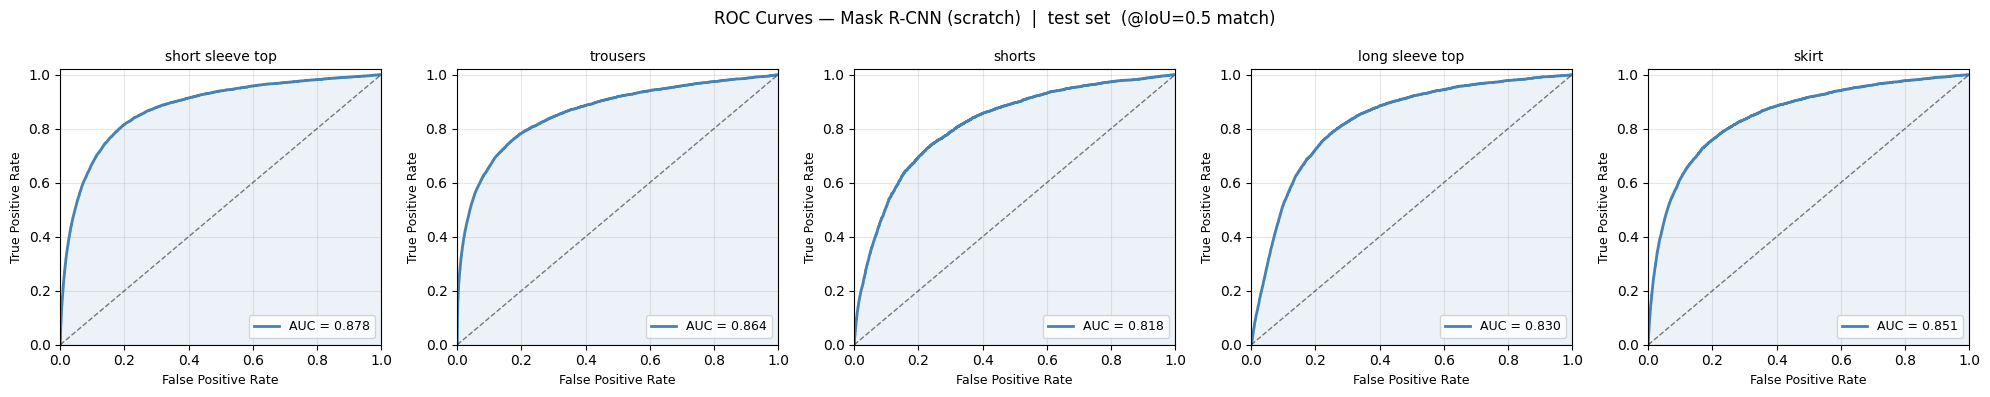

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc

def plot_roc_curves(metrics_dict, strategy="finetune", split="test", save_path=None):
    roc_raw   = metrics_dict["_roc_raw"]
    class_ids = list(roc_raw.keys())
    n         = len(class_ids)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, cls_idx in zip(axes, class_ids):
        cls_name = IDX_TO_CAT.get(cls_idx, str(cls_idx))
        y_true   = np.array(roc_raw[cls_idx]["tp_labels"], dtype=np.int32)
        y_score  = np.array(roc_raw[cls_idx]["scores"],    dtype=np.float64)

        if len(y_true) == 0 or len(np.unique(y_true)) < 2:
            ax.text(0.5, 0.5, "Insufficient\ndata",
                    ha="center", va="center", transform=ax.transAxes, fontsize=10)
            ax.set_title(cls_name, fontsize=10)
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            continue

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc     = sk_auc(fpr, tpr)

        ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {roc_auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
        ax.fill_between(fpr, tpr, alpha=0.10, color="steelblue")
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.02])
        ax.set_xlabel("False Positive Rate", fontsize=9)
        ax.set_ylabel("True Positive Rate",  fontsize=9)
        ax.set_title(cls_name, fontsize=10)
        ax.legend(loc="lower right", fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"ROC Curves — Mask R-CNN ({strategy})  |  {split} set  (@IoU=0.5 match)",
        fontsize=12
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        logger.info(f"ROC curves saved to {save_path}")
    plt.show()

plot_roc_curves(
    test_metrics,
    strategy="scratch",
    split="test",
    save_path="/kaggle/working/roc_curves_scratch_test.png"
)

## Qualitative Visualisations

2026-03-20 16:34:16,197 [INFO] Qualitative visualisations saved to /kaggle/working/qualitative_predictions_scratch.png


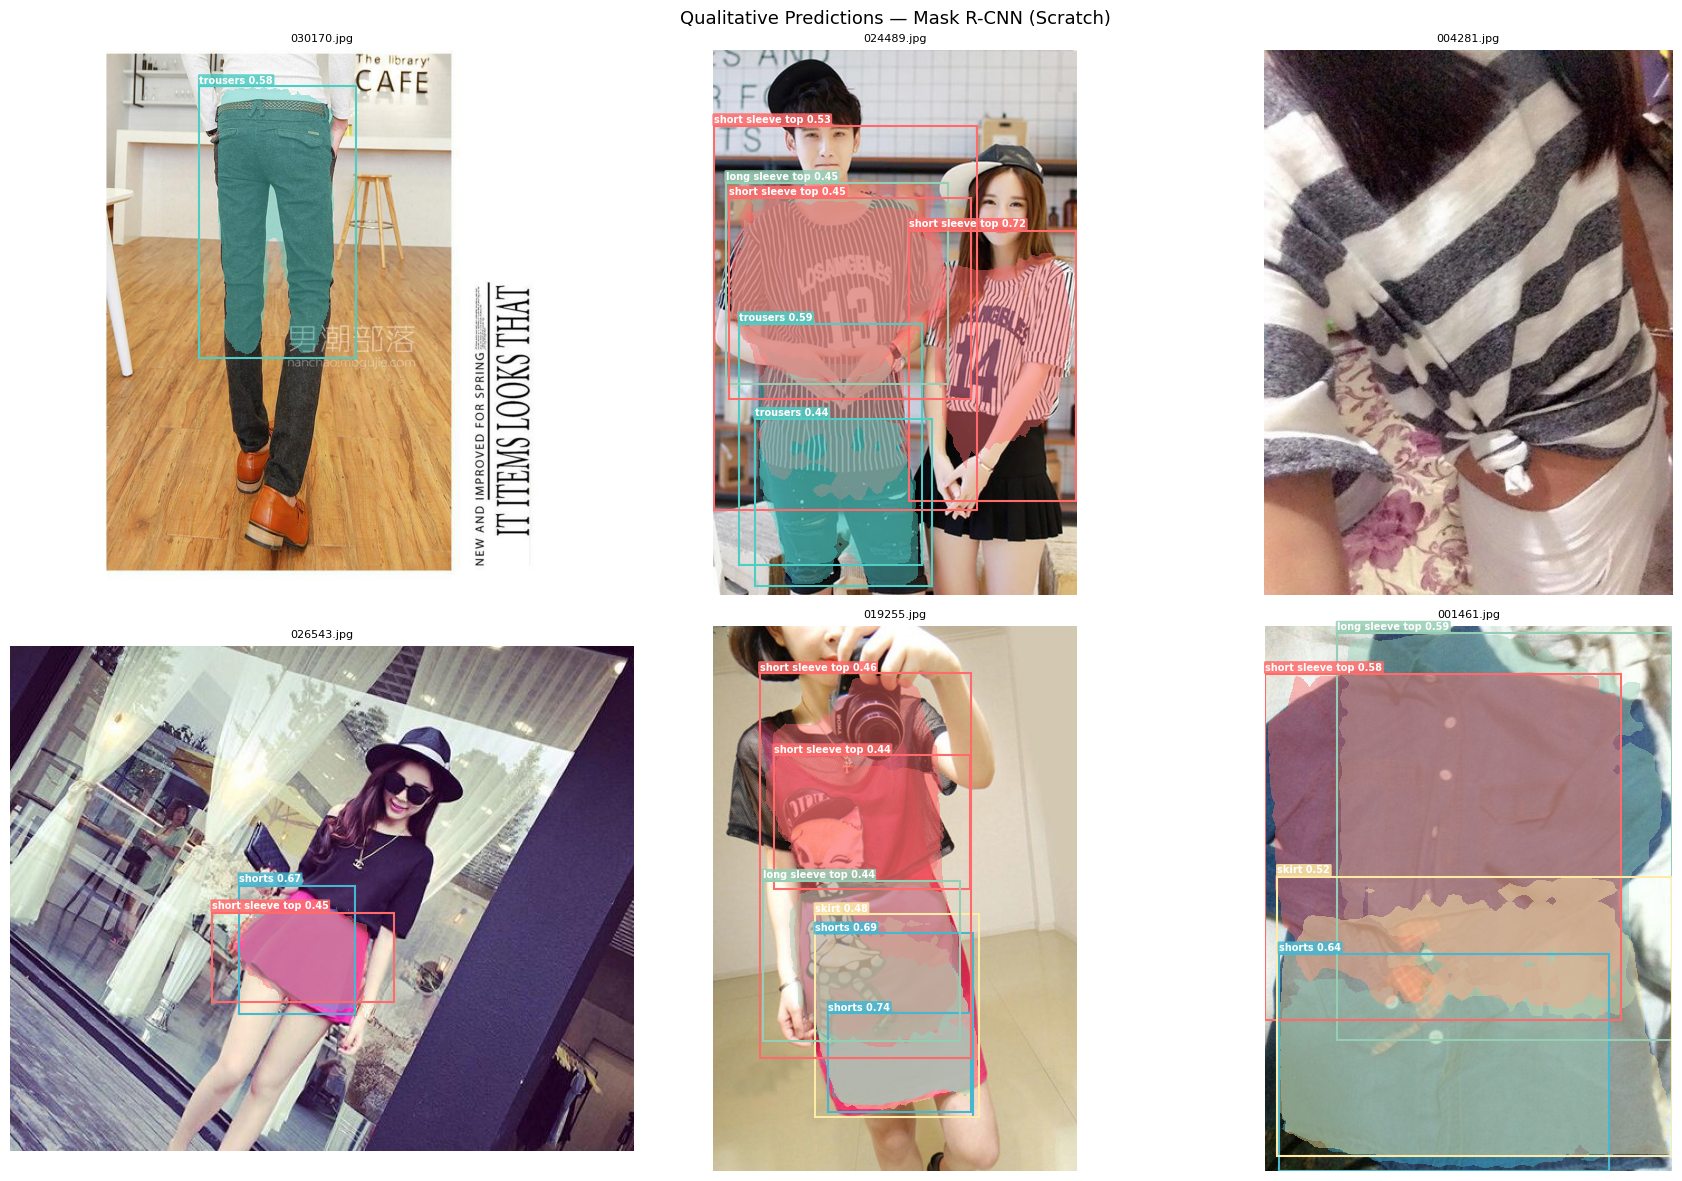

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors

CLASS_COLORS = {
    1: "#FF6B6B",   # short sleeve top
    2: "#4ECDC4",   # long sleeve top
    3: "#45B7D1",   # trousers
    4: "#96CEB4",   # shorts
    5: "#FFEAA7",   # skirt
}

def visualize_predictions(model, json_paths, device, num_images=6,
                           score_threshold=0.4, save_path=None):
    sample_paths = random.sample(json_paths, min(num_images, len(json_paths)))
    cols = 3
    rows = (len(sample_paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
    axes = np.array(axes).flatten()

    model.eval()
    for ax, jpath in zip(axes, sample_paths):
        img_path = jpath.replace(".json", ".jpg").replace("annos", "image")
        if not os.path.exists(img_path):
            img_path = jpath.replace(".json", ".jpg")
        if not os.path.exists(img_path):
            ax.axis("off"); continue

        preds  = inference_image(model, img_path, device, score_threshold=score_threshold)
        img_np = np.array(Image.open(img_path).convert("RGB"))
        ax.imshow(img_np)

        for box, label, score, mask in zip(
            preds["boxes"], preds["labels"], preds["scores"], preds["masks"]
        ):
            color_hex = CLASS_COLORS.get(int(label), "#FFFFFF")
            overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
            overlay[mask == 1] = mcolors.to_rgba(color_hex, alpha=0.45)
            ax.imshow(overlay, interpolation="nearest")
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor=color_hex, facecolor="none"
            ))
            cat = IDX_TO_CAT.get(int(label), str(label))
            ax.text(x1, max(y1 - 4, 4), f"{cat} {score:.2f}",
                    color="white", fontsize=7, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.15",
                              facecolor=color_hex, alpha=0.85, edgecolor="none"))

        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis("off")

    for ax in axes[len(sample_paths):]:
        ax.axis("off")

    plt.suptitle("Qualitative Predictions — Mask R-CNN (Scratch)", fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        logger.info(f"Qualitative visualisations saved to {save_path}")
    plt.show()

visualize_predictions(
    test_model, test_paths, device,
    num_images=6, score_threshold=0.4,
    save_path="/kaggle/working/qualitative_predictions_scratch.png"
)